In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import time
from matplotlib.colors import ListedColormap
import numpy as np

In [2]:
# Load the dataset
student_courses = pd.read_csv("../Data_sets/students_courses_dataset.csv")

student_courses.head()

,القسم,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
0,علوم طبية,1105312002,عبدالمجيد علي عبدالرحمن الشاوي,السجلات الطبية-2,110501,المهارات اللغوية,ARAB 101,211637
1,علوم طبية,1105311013,سالم سليمان دهش الشمري,السجلات الطبية-2,110501,المهارات اللغوية,ARAB 101,211637
2,علوم طبية,1105312004,احمد عبدالله صالح الحربي,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,111647
3,علوم طبية,1105321021,يوسف عبدالله سليمان المهوس,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,211647
4,علوم طبية,1105312011,سطام بندر جايز المطيري,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,211647


In [3]:
# Extract the needed columns for the evaluating the case study
courses = student_courses[['رقم الطالب', 'اسم المقرر', 'رمز المقرر']]

courses

,رقم الطالب,اسم المقرر,رمز المقرر
0,1105312002,المهارات اللغوية,ARAB 101
1,1105311013,المهارات اللغوية,ARAB 101
2,1105312004,التحرير العربي,ARAB 102
3,1105321021,التحرير العربي,ARAB 102
4,1105312011,التحرير العربي,ARAB 102
...,...,...,...
11384,1501311010,هندسة البرمجيات,342عال
11385,1401321075,هندسة البرمجيات,342عال
11386,1502301005,هندسة البرمجيات,342عال
11387,1502312010,هندسة البرمجيات,342عال


In [4]:
courses.dropna()

,رقم الطالب,اسم المقرر,رمز المقرر
0,1105312002,المهارات اللغوية,ARAB 101
1,1105311013,المهارات اللغوية,ARAB 101
2,1105312004,التحرير العربي,ARAB 102
3,1105321021,التحرير العربي,ARAB 102
4,1105312011,التحرير العربي,ARAB 102
...,...,...,...
11384,1501311010,هندسة البرمجيات,342عال
11385,1401321075,هندسة البرمجيات,342عال
11386,1502301005,هندسة البرمجيات,342عال
11387,1502312010,هندسة البرمجيات,342عال


In [5]:
# Step 1: Data Preprocessing and Graph Construction
G = nx.Graph()

# Add nodes (courses)
courses_id = courses['رمز المقرر'].unique()
G.add_nodes_from(courses_id)

# Map each student to their courses
student_courses_map = defaultdict(list)
for _, row in courses.iterrows():
    std_id = row['رقم الطالب']
    course_id = row['رمز المقرر']
    student_courses_map[std_id].append(course_id)

# Create edges (conflicts between courses)
for courses_list in student_courses_map.values():
    for i in range(len(courses_list)):
        for j in range(i + 1, len(courses_list)):
            node_A = courses_list[i]
            node_B = courses_list[j]
            if not G.has_edge(node_A, node_B):
                G.add_edge(node_A, node_B)

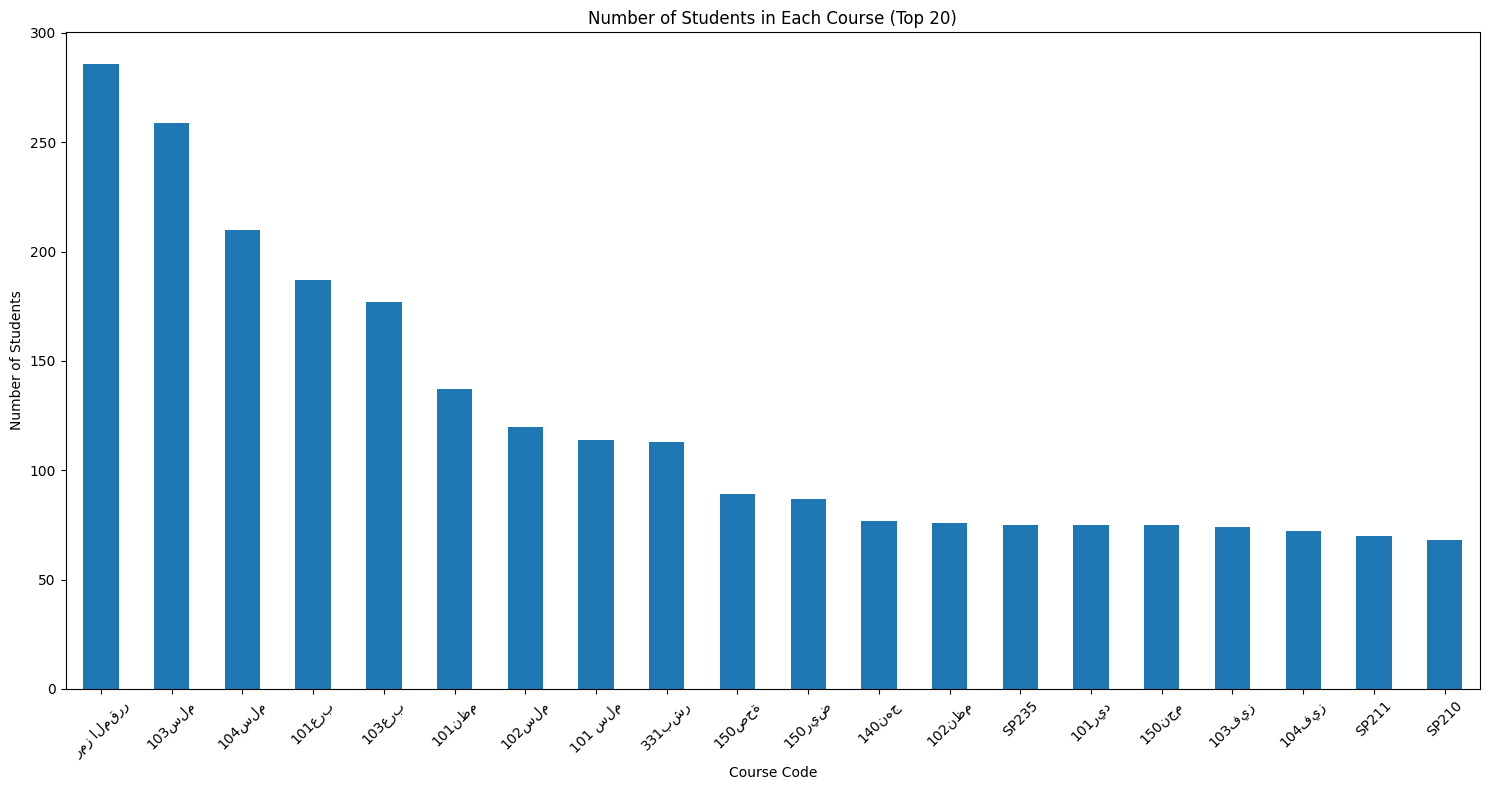

In [6]:
# Step 2: Visualization
course_counts = courses['رمز المقرر'].value_counts()

plt.figure(figsize=(15, 8))
course_counts.head(20).plot(kind='bar')
plt.title('Number of Students in Each Course (Top 20)')
plt.xlabel('Course Code')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

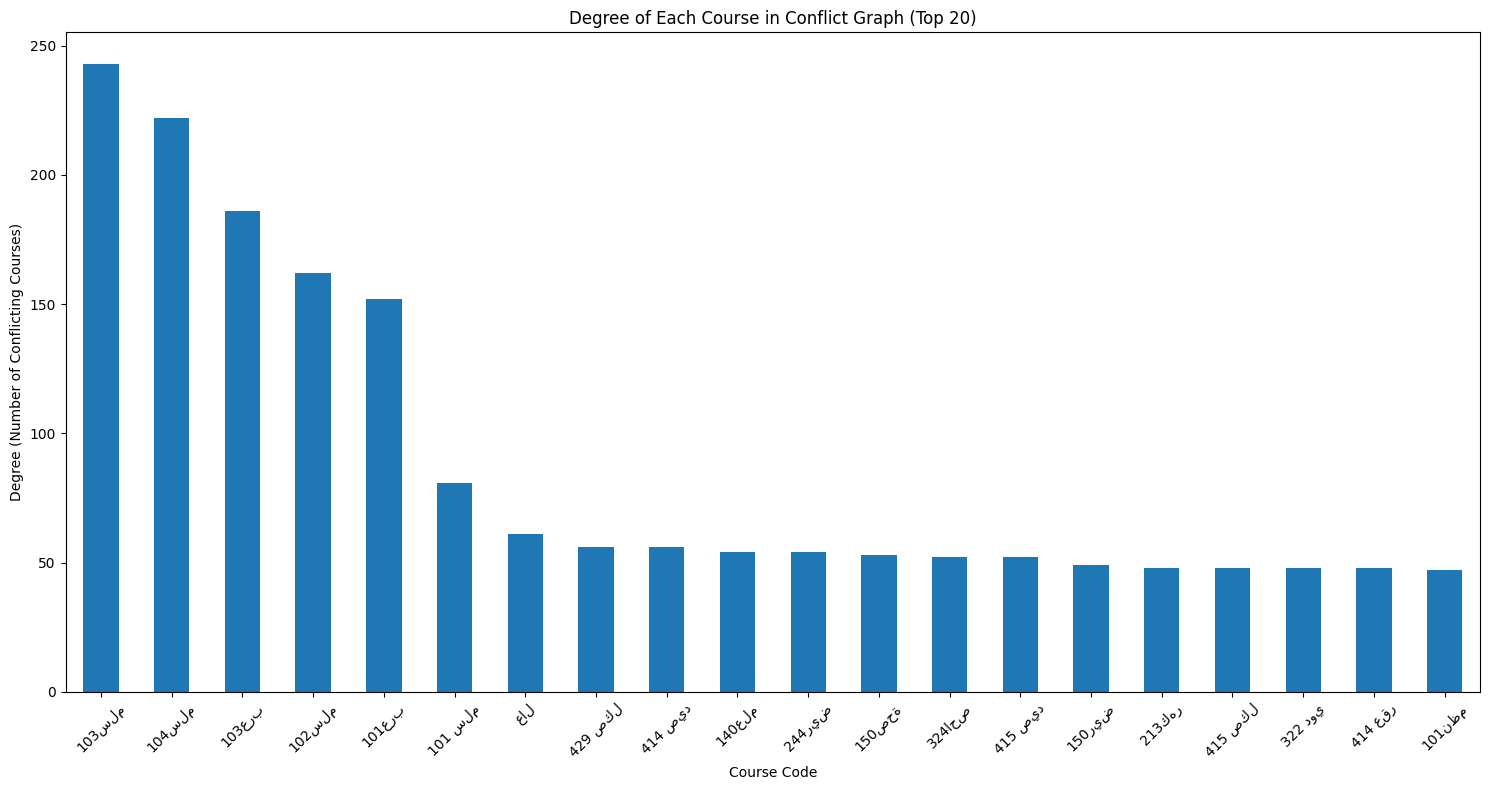

In [7]:
degrees = dict(G.degree())

plt.figure(figsize=(15, 8))
pd.Series(degrees).sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Degree of Each Course in Conflict Graph (Top 20)')
plt.xlabel('Course Code')
plt.ylabel('Degree (Number of Conflicting Courses)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Graph Statistics:
Number of courses (nodes): 480
Number of conflicts (edges): 5261
Average degree: 21.92
Maximum degree: 243
Density: 0.0458


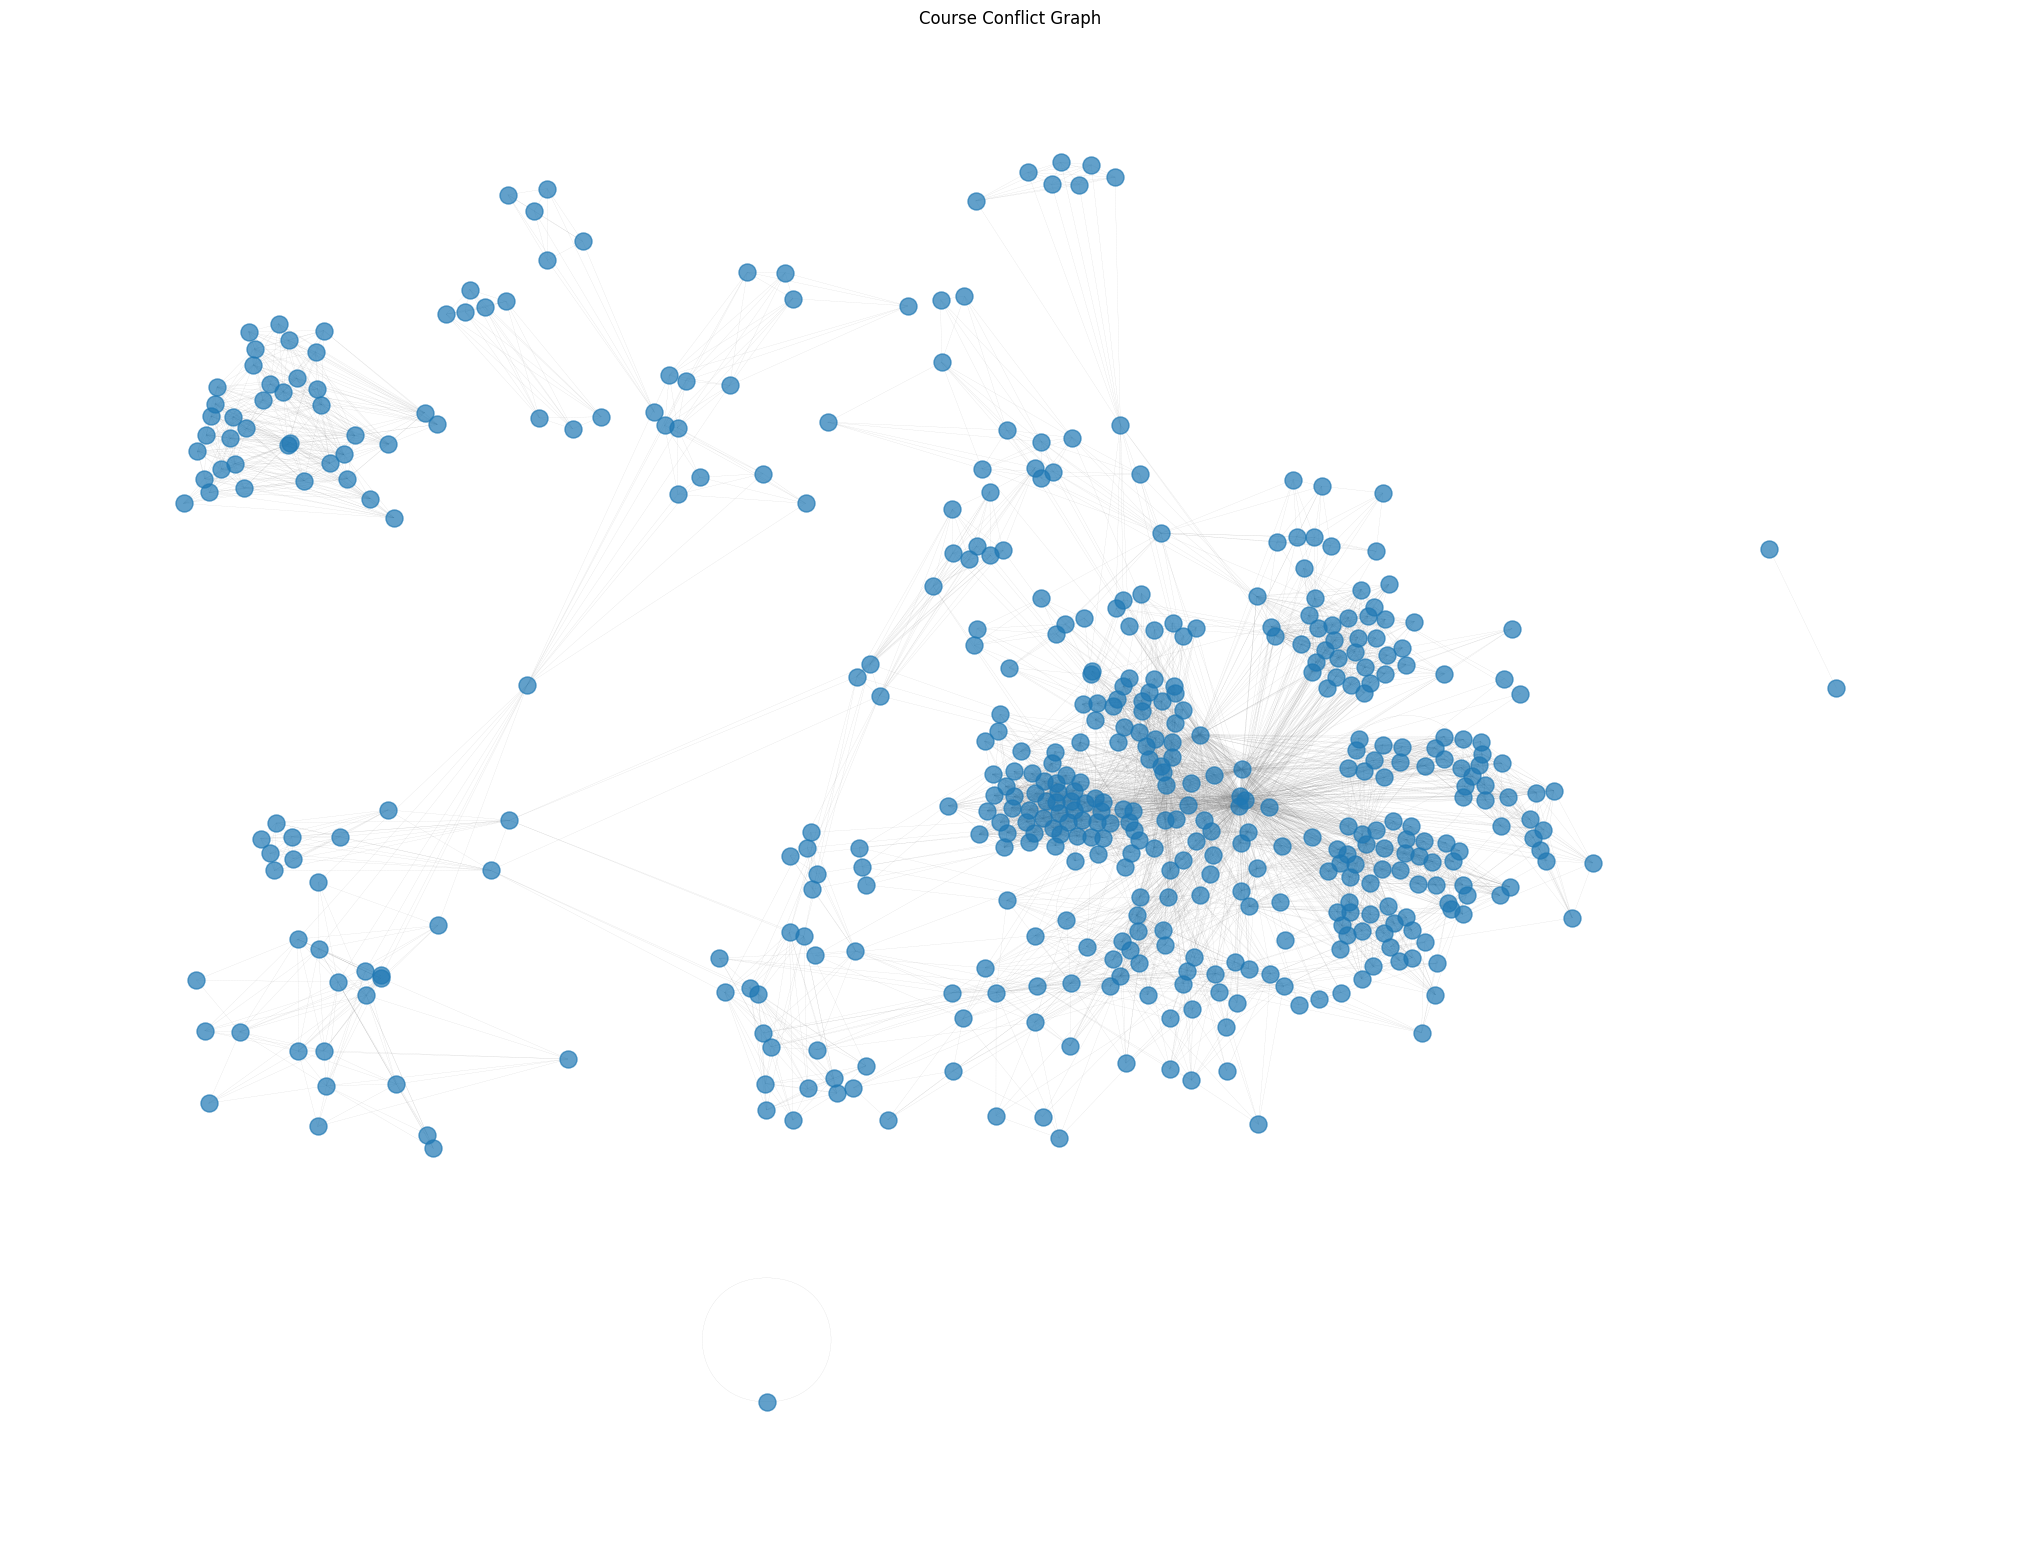

In [8]:
# Statistics
print("Graph Statistics:")
print(f"Number of courses (nodes): {G.number_of_nodes()}")
print(f"Number of conflicts (edges): {G.number_of_edges()}")
print(f"Average degree: {sum(degrees.values()) / len(degrees):.2f}")
print(f"Maximum degree: {max(degrees.values())}")
print(f"Density: {nx.density(G):.4f}")

plt.figure(figsize=(20, 15))
pos = nx.spring_layout(G, k=0.2, iterations=50)
nx.draw(G, pos, node_size=150, font_size=8, width=0.1,
        edge_color='gray', style='dashed', alpha=0.7)
plt.title("Course Conflict Graph")
plt.show()


In [9]:
# Step 3: Graph Coloring using DSATUR
start_time = time.time()
coloring = nx.greedy_color(G, strategy='DSATUR')

num_colors = len(set(coloring.values()))

print("\nDSATUR Coloring Results:")
print(f"Number of colors (exam periods) needed: {num_colors}")


DSATUR Coloring Results:
Number of colors (exam periods) needed: 19


In [10]:
# Step 4: Exam Schedule Creation
exam_schedule = defaultdict(list)
for course, color in coloring.items():
    exam_schedule[color].append(course)

print("\nExam Schedule (Periods):")
for period, courses in exam_schedule.items():
    print(f"Period {period + 1}: {len(courses)} courses")


Exam Schedule (Periods):
Period 1: 53 courses
Period 2: 46 courses
Period 3: 52 courses
Period 4: 46 courses
Period 5: 40 courses
Period 6: 43 courses
Period 7: 44 courses
Period 8: 29 courses
Period 9: 29 courses
Period 10: 25 courses
Period 11: 20 courses
Period 12: 13 courses
Period 13: 13 courses
Period 14: 9 courses
Period 15: 5 courses
Period 16: 4 courses
Period 17: 4 courses
Period 18: 3 courses
Period 19: 2 courses


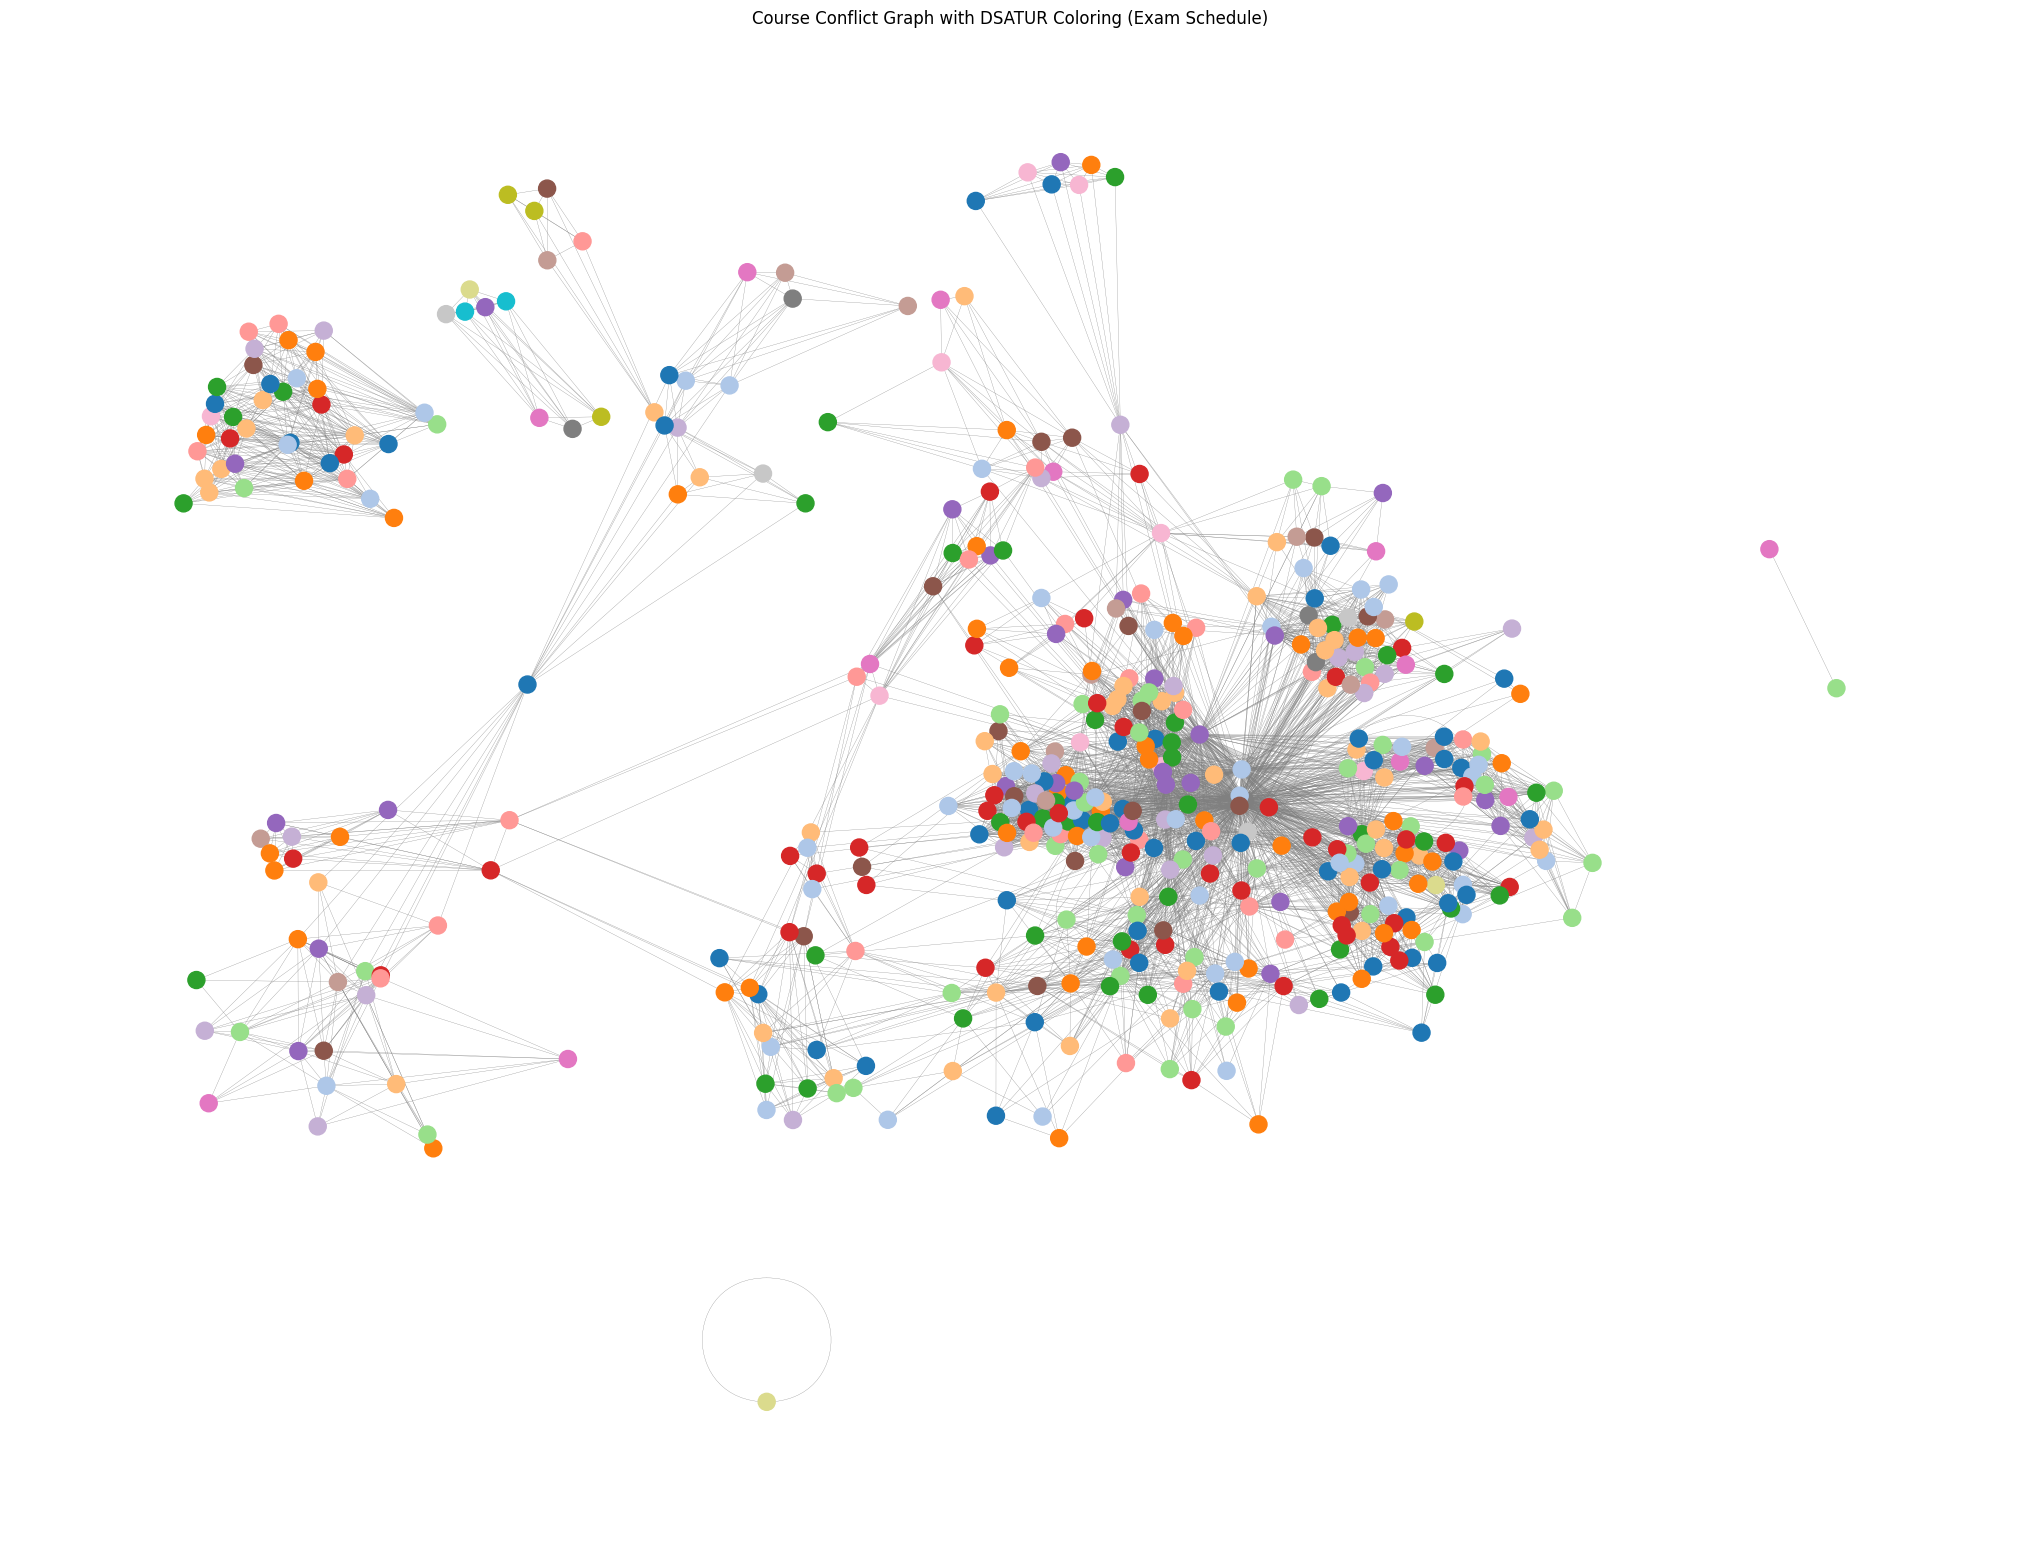

In [11]:
# Visualization with Coloring
plt.figure(figsize=(20, 15))
colors = list(coloring.values())
unique_colors = np.unique(colors)
cmap = ListedColormap(plt.cm.tab20.colors[:len(unique_colors)])

nx.draw(G, pos, node_color=colors, cmap=cmap, node_size=150,
        font_size=8, edge_color='gray', width=0.2)
plt.title("Course Conflict Graph with DSATUR Coloring (Exam Schedule)")
plt.show()

In [12]:
# Display Exam Schedule Table
schedule_df = pd.DataFrame([(f"Period {i + 1}", ', '.join(courses))
                            for i, courses in exam_schedule.items()],
                           columns=['Exam Period', 'Courses'])
print("\nDetailed Exam Schedule:")
schedule_df.head()


Detailed Exam Schedule:


,Exam Period,Courses
0,Period 1,"103سلم, 210كهر, 215 هال, 101حسب, 433بشر, حسب43..."
1,Period 2,"104سلم, 301كهر, 332كهر, 104كيم, 140 تقن, معمل1..."
2,Period 3,"103عرب, 140علم, 101كيم, 449كهر, 103كيم, 220 عا..."
3,Period 4,"102سلم, 211هعم, 403هعم, 140نهج, 113عال, 342عال..."
4,Period 5,"101عرب, 312كهر, 201هعم, 430كهر, عال, 324بشر, 1..."
